# Node Features and Graph Neural Networks

---

In this lab you will build and compare **three approaches** to node
classification, each using a different view of the data:

| Approach | Uses graph? | Uses features? | Key idea |
|----------|-------------|----------------|----------|
| **1. DeepWalk** | Yes | No | Random-walk embeddings |
| **2. MLP** | No | Yes | Learn directly from node attributes |
| **3. Vanilla GNN** | Yes | Yes | Propagate features along edges |

All three are evaluated on the **Cora** citation dataset.  By the end you
will see concretely why combining graph structure *and* node features beats
either alone.

### Prerequisites

```
pip install torch torch-geometric gensim networkx scikit-learn matplotlib
```


---
## 0. Setup

In [1]:
"""
# Install PyG (skip if already installed)
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch", "torch-geometric", "gensim", "networkx", "scikit-learn"],
    check=True,
)
"""

'\n# Install PyG (skip if already installed)\nimport subprocess, sys\nsubprocess.run(\n    [sys.executable, "-m", "pip", "install", "-q",\n     "torch", "torch-geometric", "gensim", "networkx", "scikit-learn"],\n    check=True,\n)\n'

In [2]:
# Standard imports – do not modify
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

# ---- Import YOUR implementations ----
import importlib
import student_module as sm
importlib.reload(sm)

print("Setup complete.")


Setup complete.


---
## 1. The Cora Dataset

**Cora** is a citation network of 2,708 scientific papers across 7 topics.

* **Nodes** – papers.  Each node carries a 1,433-dimensional bag-of-words
  feature vector derived from the paper's abstract.
* **Edges** – citation links (undirected).
* **Task** – predict the topic (class) of each paper.

This dataset is a perfect test-bed because it has *both* meaningful graph
structure (papers cite related work) and informative node features (abstract
text), so we can isolate the contribution of each.


In [3]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

print(f"Dataset       : {dataset}")
print(f"Graphs        : {len(dataset)}")
print(f"Nodes         : {data.num_nodes}")
print(f"Edges         : {data.num_edges}")
print(f"Node features : {dataset.num_features}")
print(f"Classes       : {dataset.num_classes}")
print(f"Train nodes   : {data.train_mask.sum().item()}")
print(f"Val nodes     : {data.val_mask.sum().item()}")
print(f"Test nodes    : {data.test_mask.sum().item()}")


c:\Users\Ректор\vs_source\GraphLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset       : Cora()
Graphs        : 1
Nodes         : 2708
Edges         : 10556
Node features : 1433
Classes       : 7
Train nodes   : 140
Val nodes     : 500
Test nodes    : 1000


### 1.1 What do the features look like?

Each node feature vector is a **bag-of-words** representation: entry $j$ is
1 if the $j$-th word in the vocabulary appears in the paper's abstract, and
0 otherwise.  The vocabulary has 1,433 words, so the feature matrix
$X \in \mathbb{R}^{2708 \times 1433}$ is very **sparse**.


In [4]:
import pandas as pd

df = pd.DataFrame(data.x.numpy())
df["label"] = data.y.numpy()

print(f"Feature matrix shape : {data.x.shape}")
print(f"Fraction of non-zeros: {data.x.mean().item():.4f}")
print(f"\nClass distribution:")
print(df["label"].value_counts().sort_index().to_string())


Feature matrix shape : torch.Size([2708, 1433])
Fraction of non-zeros: 0.0127

Class distribution:
label
0    351
1    217
2    418
3    818
4    426
5    298
6    180


https://graphsandnetworks.com/the-cora-dataset/

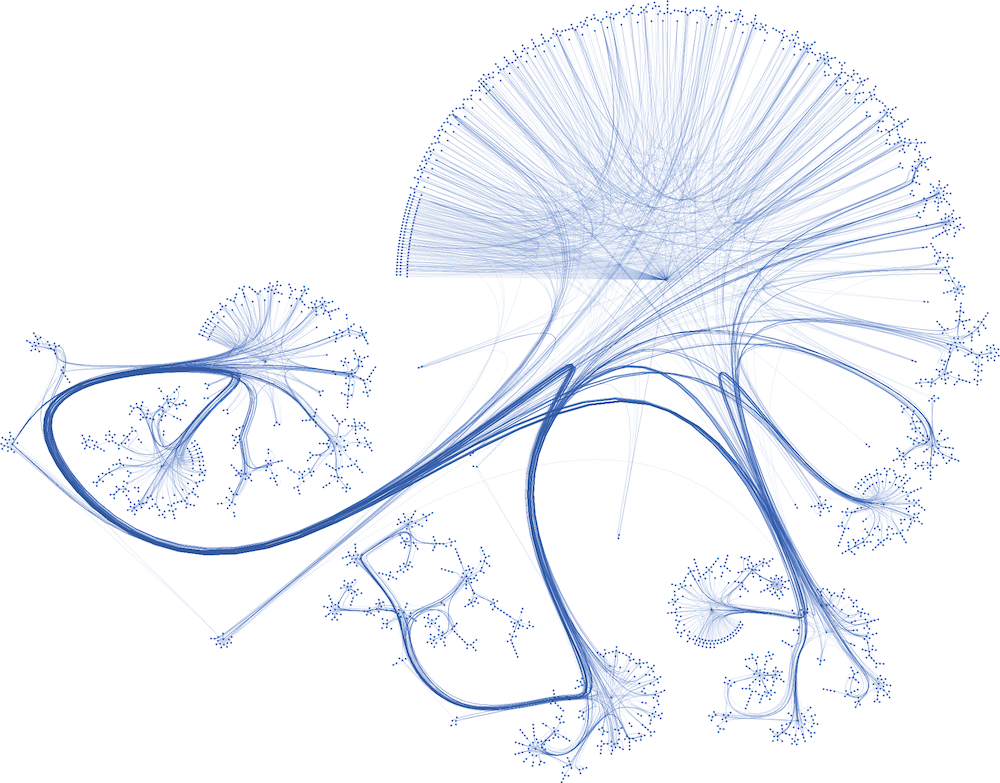

### 1.2 Visualising a subgraph

Below we draw the ego-graph of node 0 (depth 2) to get an intuition for the
local structure.  Node colour encodes the class label.


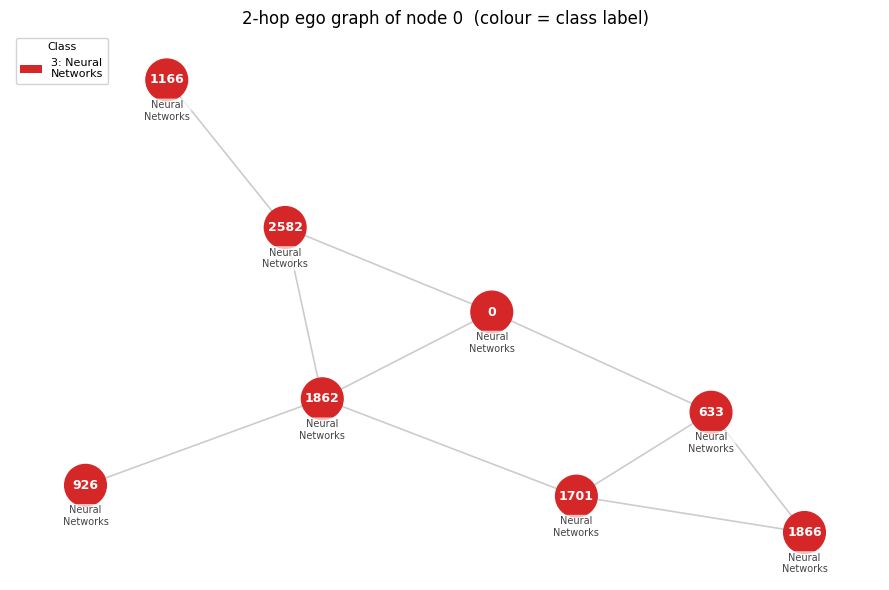

Ego-graph: 8 nodes, 10 edges


In [5]:
import networkx as nx

# Build NetworkX graph from edge_index
G_full = nx.Graph()
G_full.add_nodes_from(range(data.num_nodes))
edges = data.edge_index.t().tolist()
G_full.add_edges_from(edges)

# Extract 2-hop ego graph around node 0
ego = nx.ego_graph(G_full, 0, radius=2)

labels_np = data.y.numpy()
class_names = [
    "Theory", "Reinforcement\nLearning", "Genetic\nAlgorithms",
    "Neural\nNetworks", "Probabilistic\nMethods",
    "Case\nBased", "Rule\nLearning",
]
palette = plt.cm.tab10.colors

pos = nx.spring_layout(ego, seed=42)
node_list   = list(ego.nodes())
node_colors = [palette[labels_np[n] % 10] for n in node_list]

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title("2-hop ego graph of node 0  (colour = class label)", fontsize=12)
ax.axis("off")

# Draw edges
nx.draw_networkx_edges(ego, pos, ax=ax, edge_color="#cccccc", width=1.2)

# Draw nodes
nx.draw_networkx_nodes(
    ego, pos, ax=ax,
    nodelist=node_list,
    node_color=node_colors,
    node_size=900,
)

# Node-ID labels (white, inside the circle)
nx.draw_networkx_labels(
    ego, pos, ax=ax,
    labels={n: str(n) for n in node_list},
    font_color="white",
    font_size=9,
    font_weight="bold",
)

# Class-name annotations (just outside each node, small grey text)
offset = 0.07
for node in node_list:
    x, y = pos[node]
    cls   = labels_np[node]
    label = class_names[cls] if cls < len(class_names) else f"class {cls}"
    ax.text(
        x, y - offset, label,
        ha="center", va="top",
        fontsize=7, color="#444444",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
    )

# Legend
from matplotlib.patches import Patch
used_classes = sorted({labels_np[n] for n in node_list})
legend_elements = [
    Patch(facecolor=palette[c % 10],
          label=f"{c}: {class_names[c] if c < len(class_names) else 'class '+str(c)}")
    for c in used_classes
]
ax.legend(handles=legend_elements, loc="upper left",
          fontsize=8, framealpha=0.85, title="Class", title_fontsize=8)

plt.tight_layout()
plt.show()
print(f"Ego-graph: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")



---
## 2. Approach 1 – Shallow Embeddings (Graph Structure Only)

We begin with **DeepWalk** from the previous lab.  DeepWalk generates
node embeddings by treating random walks as sentences and training a
skip-gram Word2Vec model.  Crucially, it uses *only the graph topology*
and completely ignores any node features.

This gives us a **baseline**: how well can we classify nodes using graph
structure alone?

> We reuse `generate_walks` and `train_embedding` from the previous lab's
> teacher module.  No re-implementation needed here.


In [6]:
# Reuse DeepWalk utilities from the previous lab
from student_module_prev import generate_walks, train_embedding   # lab 3

# Convert to NetworkX for walk generation
G_cora = nx.Graph()
G_cora.add_nodes_from(range(data.num_nodes))
G_cora.add_edges_from(data.edge_index.t().tolist())

print(f"Graph: {G_cora.number_of_nodes()} nodes, {G_cora.number_of_edges()} edges")
print("Generating random walks …")

np.random.seed(0)
random.seed(0)

walks_cora = generate_walks(G_cora, num_walks=10, walk_length=20)
print(f"Corpus: {len(walks_cora)} walks")


Graph: 2708 nodes, 5278 edges
Generating random walks …
Corpus: 27080 walks


In [7]:
print("Training DeepWalk embeddings …")

model_dw = train_embedding(
    walks_cora,
    vector_size=64,
    window=10,
    epochs=5,   # keep fast for lab; increase to 30 for better accuracy
    seed=0,
)
print(f"Embedding matrix: {model_dw.wv.vectors.shape}")
print(f"\nMost similar to node 0:")
for node, sim in model_dw.wv.most_similar("0")[:5]:
    print(f"  node {node:<4}  (class {labels_np[int(node)]})  sim={sim:.3f}")


Training DeepWalk embeddings …


Embedding matrix: (2708, 64)

Most similar to node 0:
  node 1862  (class 3)  sim=0.971
  node 2582  (class 3)  sim=0.959
  node 633   (class 3)  sim=0.932
  node 926   (class 3)  sim=0.929
  node 1866  (class 3)  sim=0.877


### Task 1 – Implement `get_embedding_matrix`

Open `student_module.py` and implement `get_embedding_matrix`.

The function should take a Word2Vec `KeyedVectors` object (`model.wv`) and
a list of node IDs **as strings**, and return a single numpy array that
stacks all embedding vectors.

```
Input : wv, ['0', '1', '2']
Output: np.ndarray of shape (3, embedding_dim)
```


In [8]:
importlib.reload(sm)

node_ids_str = [str(n) for n in range(data.num_nodes)]

X_dw = sm.get_embedding_matrix(model_dw.wv, node_ids_str)

print(f"Embedding matrix shape : {X_dw.shape}")
print(f"dtype                  : {X_dw.dtype}")
print(f"Row 0 (node 0) norm    : {np.linalg.norm(X_dw[0]):.4f}")

assert isinstance(X_dw, np.ndarray), "Must return a numpy array"
assert X_dw.shape == (data.num_nodes, 64), \
    f"Expected ({data.num_nodes}, 64), got {X_dw.shape}"
print("\n✓ All checks passed!")


Embedding matrix shape : (2708, 64)
dtype                  : float32
Row 0 (node 0) norm    : 5.0991

✓ All checks passed!


### 2.2 Classify with Logistic Regression

In [9]:
# Split according to Cora's standard masks
train_idx = data.train_mask.nonzero(as_tuple=True)[0].tolist()
val_idx   = data.val_mask.nonzero(as_tuple=True)[0].tolist()
test_idx  = data.test_mask.nonzero(as_tuple=True)[0].tolist()

train_ids_str = [str(n) for n in train_idx]
test_ids_str  = [str(n) for n in test_idx]

X_train_dw = sm.get_embedding_matrix(model_dw.wv, train_ids_str)
X_test_dw  = sm.get_embedding_matrix(model_dw.wv, test_ids_str)
y_train    = labels_np[train_idx]
y_test     = labels_np[test_idx]

clf_dw = LogisticRegression(max_iter=1000, random_state=0)
clf_dw.fit(X_train_dw, y_train)
acc_dw = accuracy_score(y_test, clf_dw.predict(X_test_dw))

print(f"DeepWalk accuracy (graph only) : {acc_dw * 100:.2f}%")
# Typical range: 55–70 % with 5 epochs; better with 30


DeepWalk accuracy (graph only) : 71.60%


---
## 3. Approach 2 – MLP (Node Features Only)

Now we swing to the other extreme: **ignore the graph entirely** and train
a standard two-layer MLP directly on the 1,433-dimensional feature vectors.

The MLP sees each node in isolation.  It can learn that "a paper about
neural networks probably belongs to class 5", but it has no idea which
other papers cite it or are cited by it.

### Architecture

$$
\hat{y} = \text{softmax}\!\left( \text{ReLU}(XW_1 + b_1) \cdot W_2 + b_2 \right)
$$

where $X \in \mathbb{R}^{N \times 1433}$ is the feature matrix and
$W_1, W_2$ are learned weight matrices.


### Task 2 – Implement `MLP.forward`

Open `student_module.py` and find the `MLP` class.  Its `__init__`
already creates `self.linear1` and `self.linear2`.  Your job is to
implement `forward`:

```
x  →  linear1  →  ReLU  →  linear2  →  log_softmax  →  out
```

Return `F.log_softmax(x, dim=1)` at the end (the `fit` method uses
`CrossEntropyLoss` which expects raw logits, but `test` calls `argmax`,
which is the same either way — `log_softmax` is fine and numerically stable).


In [10]:
importlib.reload(sm)
torch.manual_seed(0)

# Quick shape check before training
mlp_test = sm.MLP(dataset.num_features, 16, dataset.num_classes)
out_test  = mlp_test(data.x)

print(f"Input  shape : {data.x.shape}")
print(f"Output shape : {out_test.shape}  (should be {data.num_nodes} x {dataset.num_classes})")

assert out_test.shape == (data.num_nodes, dataset.num_classes), \
    f"Wrong output shape: {out_test.shape}"
assert not torch.isnan(out_test).any(), "Output contains NaN!"
print("\n✓ Shape check passed!")


Input  shape : torch.Size([2708, 1433])
Output shape : torch.Size([2708, 7])  (should be 2708 x 7)

✓ Shape check passed!


### 3.2 Train and evaluate the MLP

In [11]:
importlib.reload(sm)
torch.manual_seed(0)

mlp = sm.MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
print()
mlp.fit(data, epochs=100)


MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)

Epoch   0 | Loss: 1.959 | Train Acc: 14.29% | Val Loss: 2.00 | Val Acc: 12.40%
Epoch  20 | Loss: 0.110 | Train Acc: 100.00% | Val Loss: 1.46 | Val Acc: 49.40%
Epoch  40 | Loss: 0.014 | Train Acc: 100.00% | Val Loss: 1.44 | Val Acc: 51.00%
Epoch  60 | Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.40 | Val Acc: 53.80%
Epoch  80 | Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.37 | Val Acc: 55.40%
Epoch 100 | Loss: 0.009 | Train Acc: 100.00% | Val Loss: 1.34 | Val Acc: 54.60%


In [12]:
acc_mlp = mlp.test(data)
print(f"MLP accuracy (features only) : {acc_mlp * 100:.2f}%")
# Typical: 52–56 % on Cora


MLP accuracy (features only) : 53.40%


### 3.3 What does the MLP *not* see?

The MLP treats every node independently.  The two nodes below have almost
identical feature vectors but different labels – because one is cited only
by class-0 papers and the other only by class-3 papers.  The MLP cannot
distinguish them; a GNN can.

| | Node A | Node B |
|---|---|---|
| Feature similarity | high | high |
| Neighbourhood class | 0 | 3 |
| True label | 0 | 3 |

This is the core motivation for propagating information along edges.


---
## 4. Approach 3 – Vanilla GNN (Graph + Features)

A **Vanilla GNN** combines both views.  At each layer, every node
*aggregates* the feature vectors of its neighbours:

$$
H^{(k+1)} = \sigma\!\left( \hat{A} \, H^{(k)} \, W^{(k)} \right)
$$

where

* $\hat{A} = A + I$ – the adjacency matrix with **self-loops** added
  (so each node also aggregates its own representation).
* $H^{(k)}$ – node representations at layer $k$; $H^{(0)} = X$ (raw features).
* $W^{(k)}$ – a learned weight matrix (same for all nodes at layer $k$).
* $\sigma$ – a non-linearity (ReLU between layers, log-softmax at output).

After $K$ layers, each node's embedding encodes information from its
$K$-hop neighbourhood.

> **Compare with DeepWalk:** both exploit the graph.  But DeepWalk discards
> features; GNN *starts* from them and refines via neighbourhood aggregation.

> **Compare with MLP:** both use the same $W$ matrix applied to features.
> But MLP applies it once in isolation; GNN first aggregates neighbours, so
> the same features are shared and mixed across the graph.


### Task 3 – Implement `build_adjacency`

Before running the GNN we need $\hat{A} = A + I$.

Open `student_module.py` and implement `build_adjacency`.  The function
receives a PyG `edge_index` tensor (shape `2 × E`) and the number of nodes,
and must return a dense `FloatTensor` of shape `(N, N)` where:

* `A[i, j] = 1` if there is an edge from node `i` to node `j`.
* The diagonal is at least 1 (self-loops).

**Algorithm:**
1. Start with a zero matrix.
2. Scatter ones using `edge_index`.
3. Add `torch.eye(num_nodes)` for self-loops.


In [13]:
importlib.reload(sm)

# Small sanity check first
ei_test = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]], dtype=torch.long)
A_test  = sm.build_adjacency(ei_test, num_nodes=3)

print("3-node test adjacency (with self-loops):")
print(A_test)
print(f"Diagonal (all should be 1.0): {A_test.diagonal().tolist()}")

assert A_test.shape == (3, 3), f"Wrong shape: {A_test.shape}"
assert A_test.diagonal().all(), "Self-loops missing!"
assert A_test[0, 1] == 1 and A_test[1, 0] == 1, "Edge (0,1) missing!"
print("\n✓ Small check passed!")


3-node test adjacency (with self-loops):
tensor([[1., 1., 0.],
        [1., 1., 1.],
        [0., 1., 1.]])
Diagonal (all should be 1.0): [1.0, 1.0, 1.0]

✓ Small check passed!


In [14]:
# Build the Cora adjacency matrix
importlib.reload(sm)

adjacency = sm.build_adjacency(data.edge_index, data.num_nodes)

print(f"Adjacency shape   : {adjacency.shape}")
print(f"Non-zeros         : {(adjacency > 0).sum().item()}")
print(f"Diagonal all 1    : {adjacency.diagonal().min().item() >= 1.0}")

assert adjacency.shape == (data.num_nodes, data.num_nodes)
assert adjacency.diagonal().min().item() >= 1.0, "Self-loops missing!"
print("\n✓ Cora adjacency built successfully!")


Adjacency shape   : torch.Size([2708, 2708])
Non-zeros         : 13264
Diagonal all 1    : True

✓ Cora adjacency built successfully!


### Task 4 – Implement `VanillaGNNLayer.forward`

A single GNN layer performs two operations:

1. **Linear transformation** – project each node's features to a new space.
2. **Neighbourhood aggregation** – multiply by $\hat{A}$ from the left,
   which sums the transformed features of each node's neighbours (and itself).

Formally: $\text{out} = \hat{A} \cdot (X W)$

Open `student_module.py`, find `VanillaGNNLayer`, and implement `forward`.

```python
# Hint: use @ for matrix multiplication
x = self.linear(x)      # (N, dim_in) → (N, dim_out)
x = adjacency @ x       # (N, N) @ (N, dim_out) → (N, dim_out)
```


In [15]:
importlib.reload(sm)
torch.manual_seed(0)

layer_test = sm.VanillaGNNLayer(dataset.num_features, 16)
out_layer  = layer_test(data.x, adjacency)

print(f"Input  : {data.x.shape}")
print(f"Output : {out_layer.shape}  (should be {data.num_nodes} x 16)")

assert out_layer.shape == (data.num_nodes, 16), f"Wrong shape: {out_layer.shape}"
assert not torch.isnan(out_layer).any(), "Output contains NaN!"
print("\n✓ VanillaGNNLayer check passed!")


Input  : torch.Size([2708, 1433])
Output : torch.Size([2708, 16])  (should be 2708 x 16)

✓ VanillaGNNLayer check passed!


### Task 5 – Implement `VanillaGNN.forward`

Now stack two GNN layers with a ReLU in between and log-softmax at the end:

```
(x, A)  →  gnn1  →  ReLU  →  gnn2  →  log_softmax  →  out
```

Open `student_module.py`, find `VanillaGNN`, and implement `forward`.
The `__init__` already creates `self.gnn1` and `self.gnn2`.

**Important:** pass `adjacency` to *both* GNN layers.


In [16]:
importlib.reload(sm)
torch.manual_seed(0)

gnn_test = sm.VanillaGNN(dataset.num_features, 16, dataset.num_classes)
out_gnn  = gnn_test(data.x, adjacency)

print(f"Input  : {data.x.shape}")
print(f"Output : {out_gnn.shape}  (should be {data.num_nodes} x {dataset.num_classes})")

assert out_gnn.shape == (data.num_nodes, dataset.num_classes), \
    f"Wrong shape: {out_gnn.shape}"
assert not torch.isnan(out_gnn).any(), "Output contains NaN!"
print("\n✓ VanillaGNN shape check passed!")


Input  : torch.Size([2708, 1433])
Output : torch.Size([2708, 7])  (should be 2708 x 7)

✓ VanillaGNN shape check passed!


### 4.4 Train and evaluate the Vanilla GNN

In [17]:
importlib.reload(sm)
torch.manual_seed(0)

gnn = sm.VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
print()
gnn.fit(data, adjacency, epochs=100)


VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)

Epoch   0 | Loss: 2.039 | Train Acc: 16.43% | Val Loss: 2.10 | Val Acc: 8.80%
Epoch  20 | Loss: 0.025 | Train Acc: 100.00% | Val Loss: 2.20 | Val Acc: 74.40%
Epoch  40 | Loss: 0.003 | Train Acc: 100.00% | Val Loss: 2.95 | Val Acc: 73.20%
Epoch  60 | Loss: 0.001 | Train Acc: 100.00% | Val Loss: 3.04 | Val Acc: 73.80%
Epoch  80 | Loss: 0.001 | Train Acc: 100.00% | Val Loss: 2.96 | Val Acc: 74.20%
Epoch 100 | Loss: 0.001 | Train Acc: 100.00% | Val Loss: 2.89 | Val Acc: 74.40%


In [18]:
acc_gnn = gnn.test(data, adjacency)
print(f"Vanilla GNN accuracy (graph + features): {acc_gnn * 100:.2f}%")
# Typical: 70–85 % on Cora


Vanilla GNN accuracy (graph + features): 75.10%


---
## 5. Comparison and Visualisation

Let us put all three results side by side and look at what each approach
actually learns.


In [19]:
print("=" * 50)
print(f"{'Approach':<30} {'Test Accuracy':>15}")
print("=" * 50)
print(f"{'1. DeepWalk (graph only)':<30} {acc_dw * 100:>14.2f}%")
print(f"{'2. MLP (features only)':<30} {acc_mlp * 100:>14.2f}%")
print(f"{'3. Vanilla GNN (graph+feat)':<30} {acc_gnn * 100:>14.2f}%")
print("=" * 50)


Approach                         Test Accuracy
1. DeepWalk (graph only)                71.60%
2. MLP (features only)                  53.40%
3. Vanilla GNN (graph+feat)             75.10%


### 5.2 t-SNE visualisation of learned representations

We compress the hidden-layer activations to 2D with t-SNE.  Ideally, nodes
of the same class form tight, well-separated clusters.

Each subplot shows the 2D projection coloured by ground-truth class.  A
good embedding will show 7 distinct clusters (one per Cora topic).


In [20]:
# --- Collect hidden representations ---

# 1. DeepWalk: use 64-dim embeddings directly
H_dw = sm.get_embedding_matrix(model_dw.wv, [str(n) for n in range(data.num_nodes)])

# 2. MLP: activations after the first linear layer + ReLU
H_mlp = mlp.get_hidden(data).detach().numpy()

# 3. Vanilla GNN: activations after the first GNN layer + ReLU
H_gnn = gnn.get_hidden(data, adjacency).detach().numpy()

labels_np_full = data.y.numpy()

print("Computing t-SNE projections (this may take ~30 s) …")

def tsne_2d(H, seed=0):
    return TSNE(n_components=2, learning_rate="auto", init="pca",
                random_state=seed).fit_transform(H)

T_dw  = tsne_2d(H_dw)
T_mlp = tsne_2d(H_mlp)
T_gnn = tsne_2d(H_gnn)

print("Done.")


Computing t-SNE projections (this may take ~30 s) …
Done.


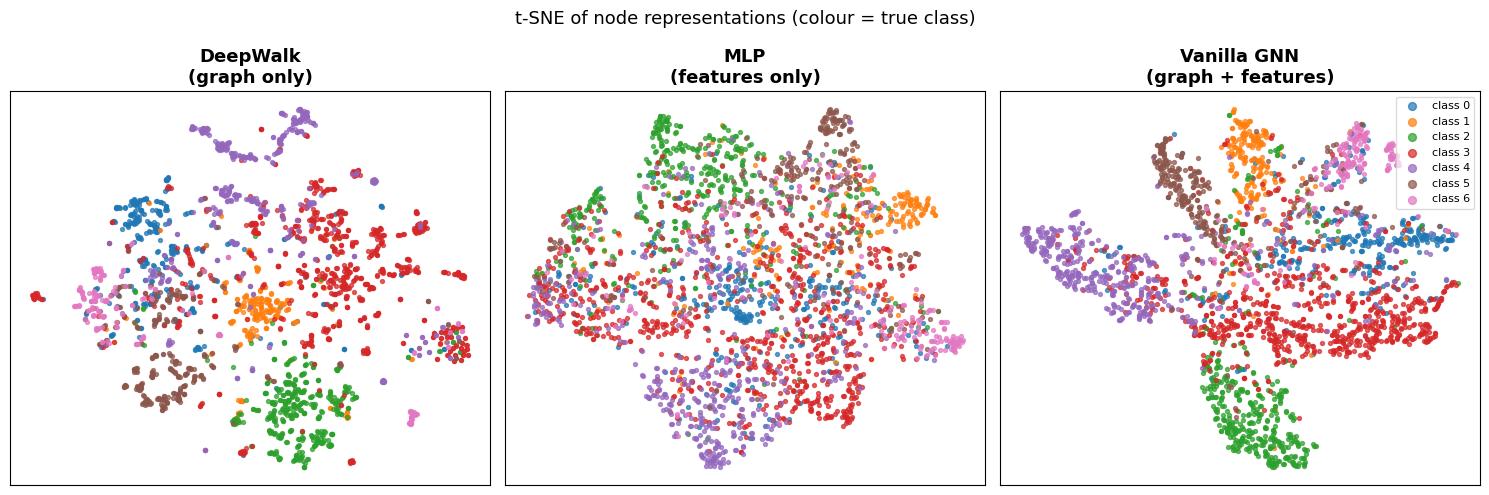

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "DeepWalk\n(graph only)",
    "MLP\n(features only)",
    "Vanilla GNN\n(graph + features)",
]
projections = [T_dw, T_mlp, T_gnn]
palette = plt.cm.tab10.colors

for ax, title, T in zip(axes, titles, projections):
    for cls in range(dataset.num_classes):
        mask = labels_np_full == cls
        ax.scatter(T[mask, 0], T[mask, 1],
                   c=[palette[cls]], s=8, alpha=0.7,
                   label=f"class {cls}")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

axes[-1].legend(
    loc="upper right", fontsize=8,
    markerscale=2, framealpha=0.7,
)

plt.suptitle("t-SNE of node representations (colour = true class)", fontsize=13)
plt.tight_layout()
plt.show()


### 5.3 Discussion

**Questions to think about:**

1. DeepWalk embeddings capture community structure well, but nodes with
   similar roles in different communities may be confused.  Which classes
   does it struggle with most in the t-SNE plot?

2. The MLP sees each node in isolation.  For Cora this works reasonably well
   because the bag-of-words features are already highly discriminative.  Can
   you think of a graph dataset where features would be *uninformative* and
   the MLP would fail completely?

3. After two GNN layers, each node's embedding aggregates information from
   its **2-hop neighbourhood**.  What is the risk of adding more layers?
   (Hint: think about what $\hat{A}^K$ converges to as $K \to \infty$.)

4. Modify `build_adjacency` to also **normalise** each row by
   the node degree:
   $$\tilde{A} = D^{-1} \hat{A}$$
   where $D_{ii} = \sum_j \hat{A}_{ij}$.
   Does this improve accuracy?  Why or why not?
